In [1]:
import os, sys
import pickle
import pandas as pd

import dask.dataframe as dd
import pyspark.sql.functions as F
from pyspark.sql.functions import pandas_udf, col

from pyspark.sql import SparkSession
from pyspark.sql import types as T
from pyspark.sql import DataFrame
from pyspark.sql.types import StringType, DoubleType, IntegerType, ArrayType, FloatType

from pyspark.ml import Pipeline, Transformer
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.linalg import Vector, Vectors, SparseVector, DenseVector, VectorUDT
from pyspark.ml.functions import vector_to_array
from pyspark.ml.stat import Summarizer
from pyspark.ml.param.shared import HasInputCol, HasOutputCol

In [3]:
spark = SparkSession.builder.master('local').appName('sb_diploma').getOrCreate()

# ga_sessions

In [4]:
df_sessions = spark.read.format('csv') \
    .option('header', 'true').load('data/ga_sessions.csv')

In [5]:
df_sessions.show(3)

+--------------------+--------------------+----------+----------+------------+--------------------+----------+--------------------+--------------------+--------------------+---------------+---------+------------+------------+------------------------+----------------+-----------+-----------+
|          session_id|           client_id|visit_date|visit_time|visit_number|          utm_source|utm_medium|        utm_campaign|       utm_adcontent|         utm_keyword|device_category|device_os|device_brand|device_model|device_screen_resolution|  device_browser|geo_country|   geo_city|
+--------------------+--------------------+----------+----------+------------+--------------------+----------+--------------------+--------------------+--------------------+---------------+---------+------------+------------+------------------------+----------------+-----------+-----------+
|90554347455899329...|2108382700.163775...|2021-11-24|  14:36:32|           1|ZpYIoDJMcFzVoPFsHGJL|    banner|LEoPHuyFvzoNfn

In [6]:
df_sessions.printSchema()

root
 |-- session_id: string (nullable = true)
 |-- client_id: string (nullable = true)
 |-- visit_date: string (nullable = true)
 |-- visit_time: string (nullable = true)
 |-- visit_number: string (nullable = true)
 |-- utm_source: string (nullable = true)
 |-- utm_medium: string (nullable = true)
 |-- utm_campaign: string (nullable = true)
 |-- utm_adcontent: string (nullable = true)
 |-- utm_keyword: string (nullable = true)
 |-- device_category: string (nullable = true)
 |-- device_os: string (nullable = true)
 |-- device_brand: string (nullable = true)
 |-- device_model: string (nullable = true)
 |-- device_screen_resolution: string (nullable = true)
 |-- device_browser: string (nullable = true)
 |-- geo_country: string (nullable = true)
 |-- geo_city: string (nullable = true)



In [7]:
df_sessions.count()

1860042

### Columns to drop

In [8]:
def count_isnull_rows(df):
    for col in df.columns:
        null_count = df.filter(F.col(col).isNull()).count()
        if null_count != 0:
            print(f"{col}: {null_count}")

count_isnull_rows(df_sessions)

utm_source: 97


utm_campaign: 219603


utm_adcontent: 335615


utm_keyword: 1082061


device_os: 1070138


device_brand: 367178


device_model: 1843704


In [9]:
col_to_drop = ['visit_number', 'visit_date', 'utm_campaign', 'utm_adcontent', 'utm_keyword', 'device_model', 'visit_time']

df_sessions_2 = df_sessions.drop(*col_to_drop)

## Duplicates

### session_id

In [10]:
df_sessions_2.groupBy('session_id').agg(F.count('session_id')).count()

1860042

In [11]:
df_sessions_2.groupBy('client_id').agg(F.count('client_id')).count()

1391719

In [12]:
df_sessions_2.groupBy('client_id').agg(F.count('client_id')).show(5, truncate=50)

+---------------------+----------------+
|            client_id|count(client_id)|
+---------------------+----------------+
|2108827456.1624376245|               2|
| 210935690.1630738865|               4|
|2109638794.1635655957|               2|
|2110276271.1638980134|               1|
|2110798440.1631774074|               1|
+---------------------+----------------+
only showing top 5 rows


In [13]:
df_sessions_2.filter(F.col('client_id') == '210935690.1630738865').select('session_id', 'client_id', 'utm_source', 'utm_medium').show(truncate=100)

+----------------------------------------+--------------------+--------------------+----------+
|                              session_id|           client_id|          utm_source|utm_medium|
+----------------------------------------+--------------------+--------------------+----------+
|905961891739933105.1630738866.1630738866|210935690.1630738865|kjsLglQLzykiRbcDiGcD|       cpc|
|905961891739933105.1630738875.1630738875|210935690.1630738865|kjsLglQLzykiRbcDiGcD|       cpc|
|905961891739933105.1630738892.1630738892|210935690.1630738865|kjsLglQLzykiRbcDiGcD|       cpc|
|905961891739933105.1630738894.1630738894|210935690.1630738865|kjsLglQLzykiRbcDiGcD|       cpc|
+----------------------------------------+--------------------+--------------------+----------+



In [14]:
f_session_id_split = lambda x: x.split('.')[0]
f_udf = F.udf(f_session_id_split, StringType())

df_sessions_3 = df_sessions_2.withColumn('session_id', f_udf(F.col('session_id')))

In [15]:
df_sessions_3.groupBy('session_id').agg(F.count('session_id')).count()

1391719

In [16]:
df_sessions_4 = df_sessions_3.dropDuplicates()
df_sessions_4.count()

1515673

### binary features

In [17]:
df_sessions_4.groupBy('client_id').agg(F.count('utm_medium').alias('count')).orderBy(F.desc('count')).show(3, truncate=50)

+---------------------+-----+
|            client_id|count|
+---------------------+-----+
|1136708344.1633419274|   27|
|1750498477.1629450062|   22|
|  75736298.1623138381|   21|
+---------------------+-----+
only showing top 3 rows


In [18]:
df_sessions_4.groupBy('client_id').agg(F.count('utm_source').alias('count')).orderBy(F.desc('count')).show(3, truncate=50)

+---------------------+-----+
|            client_id|count|
+---------------------+-----+
|1136708344.1633419274|   27|
|1750498477.1629450062|   22|
|  75736298.1623138381|   21|
+---------------------+-----+
only showing top 3 rows


In [19]:
df_sessions_4.filter(F.col('client_id') == '1750498477.1629450062').select('client_id', 'utm_medium').show()

+--------------------+----------+
|           client_id|utm_medium|
+--------------------+----------+
|1750498477.162945...|       cpc|
|1750498477.162945...|       cpc|
|1750498477.162945...|  referral|
|1750498477.162945...|  referral|
|1750498477.162945...|  referral|
|1750498477.162945...|       cpc|
|1750498477.162945...|   organic|
|1750498477.162945...|  referral|
|1750498477.162945...|   organic|
|1750498477.162945...|   organic|
|1750498477.162945...|       cpc|
|1750498477.162945...|       cpc|
|1750498477.162945...|       cpc|
|1750498477.162945...|       cpc|
|1750498477.162945...|   organic|
|1750498477.162945...|   organic|
|1750498477.162945...|       cpc|
|1750498477.162945...|  referral|
|1750498477.162945...|  referral|
|1750498477.162945...|  referral|
+--------------------+----------+
only showing top 20 rows


In [20]:
""" 
Функция для разметки бинарных признаков 'utm_source' и 'utm_medium'
"""
def utm_udf(arg_list: list):
    
    @pandas_udf(returnType=StringType())
    def wrapper(column: pd.Series) -> str:
        
        for value in column:
            if value in arg_list:
                return value
        
        return value
    
    return wrapper


binary_args = {
    'utm_source': [
        'QxAxdyPLuQMEcrdZWdWb', 'MvfHsxITijuriZxsqZqt', 'ISrKoXQCxqqYvAZICvjs',
        'IZEXUFLARCUMynmHNBGo', 'PlbkrSYoHuZBWfYjYnfw', 'gVRrcxiDQubJiljoTbGm'
    ], 
    'utm_medium': ['organic', 'referral', '(none)']
}


f_utm_source_udf = utm_udf(binary_args['utm_source'])
f_utm_medium_udf = utm_udf(binary_args['utm_medium'])

In [21]:
df_utm = df_sessions_4.groupBy('client_id').agg(f_utm_source_udf('utm_source').alias('utm_source'),
                                                              f_utm_medium_udf('utm_medium').alias('utm_medium'))                                                                    

In [22]:
df_utm.count()

1391719

In [24]:
df_utm.show(5)

+--------------------+--------------------+----------+
|           client_id|          utm_source|utm_medium|
+--------------------+--------------------+----------+
|1000000719.163438...|BHcvLfOaCWvWTykYqHVe|       cpc|
| 10000026.1621927845|aXQzDWsJuGXeBXexNHjc|    (none)|
|1000002812.163265...|BHcvLfOaCWvWTykYqHVe|  referral|
|1000004514.163101...|PlbkrSYoHuZBWfYjYnfw|       cpm|
|1000005466.162326...|fDLlAcSmythWSCVMvqvL|    (none)|
+--------------------+--------------------+----------+
only showing top 5 rows


### categorical features

In [25]:
df_sessions_2.select(df_sessions_2.columns[5:]).show(3)

+---------+------------+------------------------+----------------+-----------+-----------+
|device_os|device_brand|device_screen_resolution|  device_browser|geo_country|   geo_city|
+---------+------------+------------------------+----------------+-----------+-----------+
|  Android|      Huawei|                 360x720|          Chrome|     Russia|   Zlatoust|
|  Android|     Samsung|                 385x854|Samsung Internet|     Russia|     Moscow|
|  Android|      Huawei|                 360x720|          Chrome|     Russia|Krasnoyarsk|
+---------+------------+------------------------+----------------+-----------+-----------+
only showing top 3 rows


In [26]:
df_sessions_2.groupBy('client_id').agg(F.count('device_category').alias('count')).orderBy(F.desc('count')).show(3, truncate=50)

+---------------------+-----+
|            client_id|count|
+---------------------+-----+
|1750498477.1629450062|  462|
| 130918396.1628014141|  334|
|1266574870.1623140118|  309|
+---------------------+-----+
only showing top 3 rows


In [27]:
df_sessions_2.filter(F.col('client_id') == '1750498477.1629450062').select('client_id', 'device_category') \
.groupBy('device_category').agg(F.count('device_category')).show()

+---------------+----------------------+
|device_category|count(device_category)|
+---------------+----------------------+
|        desktop|                   461|
|         mobile|                     1|
+---------------+----------------------+



In [64]:
# mode

### drop client_id duplicates 

In [28]:
df_sessions_4.columns[2:]

['utm_source',
 'utm_medium',
 'device_category',
 'device_os',
 'device_brand',
 'device_screen_resolution',
 'device_browser',
 'geo_country',
 'geo_city']

In [29]:
df_session_5 = df_sessions_4.groupBy('session_id', 'client_id').agg(F.mode('device_category').alias('device_category'),
                                                                    F.mode('device_os').alias('device_os'),
                                                                    F.mode('device_brand').alias('device_brand'),
                                                                    F.mode('device_screen_resolution').alias('device_screen_resolution'),
                                                                    F.mode('device_browser').alias('device_browser'),
                                                                    F.mode('geo_country').alias('geo_country'),
                                                                    F.mode('geo_city').alias('geo_city'))

In [30]:
print(df_session_5.count(), len(df_session_5.columns))

1391719 9


### df_full

In [33]:
df_full = df_session_5.join(df_utm, on='client_id')

In [34]:
df_full.count()

1391719

In [35]:
df_full.show(3)

+--------------------+-------------------+---------------+---------+------------+------------------------+----------------+-----------+----------------+--------------------+----------+
|           client_id|         session_id|device_category|device_os|device_brand|device_screen_resolution|  device_browser|geo_country|        geo_city|          utm_source|utm_medium|
+--------------------+-------------------+---------------+---------+------------+------------------------+----------------+-----------+----------------+--------------------+----------+
|1000002812.163265...|4294979375080690474|         mobile|     NULL|      Huawei|                 360x760|       YaBrowser|     Russia|Saint Petersburg|BHcvLfOaCWvWTykYqHVe|  referral|
|1000004514.163101...|4294986685113389448|        desktop|     NULL|        NULL|               2560x1400|          Chrome|     Russia|          Moscow|PlbkrSYoHuZBWfYjYnfw|       cpm|
|1000005466.162326...|4294990773914503645|         mobile|     NULL|     Sa

In [36]:
df_full.write.mode('overwrite').parquet("preprocessed_data/df_full.parquet")

# ga_hits

In [37]:
df_hits = spark.read.format('csv') \
    .option('header', 'true').load('data/ga_hits.csv')

In [38]:
df_hits.printSchema()

root
 |-- session_id: string (nullable = true)
 |-- hit_date: string (nullable = true)
 |-- hit_time: string (nullable = true)
 |-- hit_number: string (nullable = true)
 |-- hit_type: string (nullable = true)
 |-- hit_referer: string (nullable = true)
 |-- hit_page_path: string (nullable = true)
 |-- event_category: string (nullable = true)
 |-- event_action: string (nullable = true)
 |-- event_label: string (nullable = true)
 |-- event_value: string (nullable = true)



In [39]:
df_hits.count()

15726470

In [40]:
df_hits.show(3)

+--------------------+----------+--------+----------+--------+-----------+--------------------+--------------+------------+-----------+-----------+
|          session_id|  hit_date|hit_time|hit_number|hit_type|hit_referer|       hit_page_path|event_category|event_action|event_label|event_value|
+--------------------+----------+--------+----------+--------+-----------+--------------------+--------------+------------+-----------+-----------+
|56396230787127240...|2021-12-23|597864.0|        30|   event|       NULL|sberauto.com/cars...|          quiz|   quiz_show|       NULL|       NULL|
|77503522949691150...|2021-12-23|597331.0|        41|   event|       NULL|sberauto.com/cars...|          quiz|   quiz_show|       NULL|       NULL|
|88534219184799824...|2021-12-23|796252.0|        49|   event|       NULL|sberauto.com/cars...|          quiz|   quiz_show|       NULL|       NULL|
+--------------------+----------+--------+----------+--------+-----------+--------------------+--------------+--

In [41]:
df_hits.groupBy('session_id').agg(F.count('session_id')).count()

1734610

### target

In [42]:
target_event_action = [
    'sub_car_claim_click', 'sub_car_claim_submit_click', 'sub_open_dialog_click', 
    'sub_custom_question_submit_click','sub_call_number_click', 'sub_callback_submit_click',
    'sub_submit_success', 'sub_car_request_submit_click'
]


""" 
Класс для разметки целевого признака event action и группировки по session_id.
"""

class Target(Transformer, HasInputCol):
    TARGETS = target_event_action
    
    def __init__(self, inputCol=None):
        super(Target, self).__init__()
        self.input_col = inputCol

    def _transform(self, df: DataFrame) -> DataFrame:
        f_session_id_split = lambda x: x.split('.')[0]
        f_udf = F.udf(f_session_id_split, StringType())
        
        df = df.withColumn('target', F.when(F.col(self.input_col).isin(self.TARGETS), 1).otherwise(0))
        df = df.withColumn('session_id', f_udf(F.col('session_id')))
        df = df.groupBy('session_id').agg(F.max(F.col('target')).alias('target'))

        return df

In [44]:
gbd = Target('event_action')

df_target = gbd.transform(df_hits)

df_target.count()

1320814

In [45]:
df_target.show(5, truncate=30)

+-------------------+------+
|         session_id|target|
+-------------------+------+
|8730506077214554578|     0|
|5078070162188676092|     0|
|3525042668361258850|     0|
|4517724170129541991|     0|
|3529775924184910289|     0|
+-------------------+------+
only showing top 5 rows


In [46]:
df_target.write.mode('overwrite').parquet("preprocessed_data/target.parquet")

# Pipeline

In [48]:
import tqdm
import dill
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, auc, accuracy_score, roc_curve

from sklearn.utils import resample
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier, VotingClassifier, RandomForestClassifier


from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, FunctionTransformer

In [49]:
df_full = pd.read_parquet("preprocessed_data/df_full.parquet")

df_full.head()

,client_id,session_id,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city,utm_source,utm_medium
0,1000002812.1632654122,4294979375080690474,mobile,None,Huawei,360x760,YaBrowser,Russia,Saint Petersburg,BHcvLfOaCWvWTykYqHVe,referral
1,1000004514.1631015304,4294986685113389448,desktop,None,None,2560x1400,Chrome,Russia,Moscow,PlbkrSYoHuZBWfYjYnfw,cpm
2,1000005466.1623263709,4294990773914503645,mobile,None,Samsung,384x854,Samsung Internet,Russia,Surgut,fDLlAcSmythWSCVMvqvL,(none)
3,1000015031.1635542138,4295031855288968314,mobile,Android,Huawei,360x780,Chrome,Russia,Vladivostok,jaSOmLICuBzCFqHfBdRg,email
4,1000017195.1629232068,4295041149591886788,tablet,None,Huawei,534x854,Chrome,Russia,Moscow,fDLlAcSmythWSCVMvqvL,(none)


In [50]:
df_full.shape

(1391719, 11)

In [51]:
df_target = pd.read_parquet("preprocessed_data/target.parquet")

In [52]:
df_target.head()

,session_id,target
0,8730506077214554578,0
1,5078070162188676092,0
2,3525042668361258850,0
3,4517724170129541991,0
4,3529775924184910289,0


In [53]:
df_target.shape

(1320814, 2)

In [54]:
client_dataset = pd.merge(left=df_target, right=df_full, on='session_id')

### target statistics

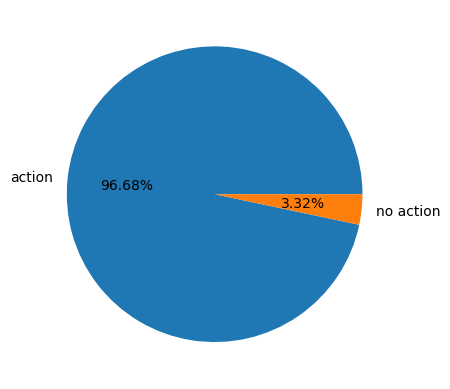

In [55]:
def get_target_balance(target: pd.DataFrame) -> None:
    labels = ['action', 'no action']
    plt.pie(target.value_counts(), labels=labels, autopct='%1.2f%%')
    plt.show()

get_target_balance(client_dataset['target'])

# Preprocessors

In [58]:
client_dataset.iloc[:, 3:].head()

,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city,utm_source,utm_medium
0,desktop,Windows,None,1920x1080,Chrome,Russia,Moscow,kjsLglQLzykiRbcDiGcD,organic
1,mobile,Android,Huawei,360x720,Chrome,Russia,Rostov-on-Don,ZpYIoDJMcFzVoPFsHGJL,banner
2,mobile,iOS,Apple,414x896,Safari (in-app),Russia,Moscow,fDLlAcSmythWSCVMvqvL,(none)
3,desktop,Windows,None,2560x1440,Edge,Russia,Moscow,IZEXUFLARCUMynmHNBGo,blogger_channel
4,desktop,Windows,None,2048x1152,Chrome,Russia,Moscow,IZEXUFLARCUMynmHNBGo,referral


### utm features

In [61]:
"""
Класс для разметки признаков utm_source и utm_medium.
"""


class BinaryClassificator(BaseEstimator, TransformerMixin):
    
    def __init__(self, input_data: dict):
        super(BinaryClassificator, self).__init__()
        self.input_data = input_data

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        for k, v in self.input_data.items():
            X[k] = X[k].apply(lambda x: 1 if x in v else 0)
        
        return X


binary_args = {
    'utm_source': [
        'QxAxdyPLuQMEcrdZWdWb', 'MvfHsxITijuriZxsqZqt', 'ISrKoXQCxqqYvAZICvjs',
        'IZEXUFLARCUMynmHNBGo', 'PlbkrSYoHuZBWfYjYnfw', 'gVRrcxiDQubJiljoTbGm'
    ], 
    'utm_medium': ['organic', 'referral', '(none)']
}


binary_clf = BinaryClassificator(binary_args)

### categoricat features(device, geo)

In [62]:
# cat_features = client_dataset.iloc[:, 4:-2].columns

# for col in cat_features:
#     print(client_dataset[col].value_counts().head(20))

In [63]:
"""
Класс для разметки признаков категориальных признаков(device, geo).
"""

class CategoryClassificator(BinaryClassificator):

    @staticmethod
    def splitter(x, category_list):
        if x:
            x = x.split()[0]
            if x in category_list:
                return x
            else:
                return 'other'
        return 'other'
    
    def transform(self, X):
        for k, v in self.input_data.items():
            X[k] = X[k].apply(lambda x: self.splitter(x, v))
        return X


"""
Класс для ohe кодироавания категориальных признаков(device, geo).
"""

class Encoder(BinaryClassificator):

    def fit(self, X, y=None):
        self.encoder = OneHotEncoder(sparse_output=False)
        self.encoder.fit(X[self.input_data.keys()])
        
        return self

    def transform(self, X):
        feature_names = self.encoder.get_feature_names_out()
        X[feature_names] = self.encoder.transform(X[self.input_data.keys()])
                
        return X.drop(self.input_data.keys(), axis=1)


ohe_args = {
    'device_category': ['mobile', 'desktop', 'tablet'], 
    'device_brand': ['Apple', 'Samsung', 'Xiaomi', 'Huawei'],
    'device_os': ['Android', 'iOS', 'Windows', 'Macintosh', 'Linux'],
    'device_screen_resolution': ['1920x1080', '2560x1440', '3840x2160', '2560x1080', '3440x1440', '1440x900', '1280x720'],
    'device_browser': ['Chrome', 'Safari', 'YaBrowser', 'Samsung', 'Android', 'Opera', 'Firefox', 'Edge'], 
    'geo_country': ['Russia'],
    'geo_city': [
        'Moscow', 'Saint Petersburg', 'Yekaterinburg', 'Nizhny Novgorod', 
        'Kazan', 'Samara', 'Krasnodar', 'Ufa', 
        'Novosibirsk', 'Krasnoyarsk', 'Chelyabinsk', 'Tula', 
        'Rostov-on-Don', 'Irkutsk', 'Vladivostok', 'Grozny'
    ]
}


category_clf = CategoryClassificator(ohe_args)
encoder = Encoder(ohe_args)

### resample

In [66]:
"""Функция для уменьшения размерности."""

def get_df_resampled(X):
    df_min = X[X['target'] == 1]
    df_maj = X[X['target'] == 0]
    df_downupsample = resample(df_maj, replace=True, n_samples=len(df_min), random_state=42)

    return pd.concat([df_min, df_downupsample], ignore_index=True).sample(frac=1.)


"""
Функция разделяет выборки на df_train и df_test, понижает размерность df_train.
"""

def save_and_get_resampled_df(df: pd.DataFrame, random_state: int, save_to_path=None) -> tuple:
    
    df_train, df_test = train_test_split(df, test_size=0.3, stratify=df['target'], random_state=random_state)

    df_train = get_df_resampled(df_train)

    return df_train, df_test

In [67]:
df_train, df_test = save_and_get_resampled_df(
    df=client_dataset, 
    random_state=42
)

print(df_train.shape)
print(df_test.shape)

(61438, 12)
(396213, 12)


# Feature selection

In [68]:
class MMScaler(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        self.scaler = MinMaxScaler()
        self.scaler.fit(X)
        self.std_features = self.scaler.get_feature_names_out()
        return self

    def transform(self, X):
        X.loc[:, self.std_features] = self.scaler.transform(X.loc[:, self.std_features])
        return X

scaler = MMScaler()

In [70]:
X = df_train.drop(['target', 'session_id', 'client_id'], axis=1)
y = df_train['target']

cat_model = CatBoostClassifier(verbose=0)

pipe = Pipeline(steps=[
    ('binary_classificator', binary_clf),
    ('classificator', category_clf),
    ('encoder', encoder),
    ('scaler', scaler),
    ('estimator', cat_model)
]) 

pipe.fit(X, y)

,steps,"[('binary_classificator', ...), ('classificator', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,input_data,"{'utm_medium': ['organic', 'referral', ...], 'utm_source': ['QxAxdyPLuQMEcrdZWdWb', 'MvfHsxITijuriZxsqZqt', ...]}"
,input_data,"{'device_brand': ['Apple', 'Samsung', ...], 'device_browser': ['Chrome', 'Safari', ...], 'device_category': ['mobile', 'desktop', ...], 'device_os': ['Android', 'iOS', ...], ...}"
,input_data,"{'device_brand': ['Apple', 'Samsung', ...], 'device_browser': ['Chrome', 'Safari', ...], 'device_category': ['mobile', 'desktop', ...], 'device_os': ['Android', 'iOS', ...], ...}"


In [71]:
model = pipe.named_steps['estimator']

imp_dict = dict(zip(model.feature_names_, model.feature_importances_))

imp_dict_sorted = dict(sorted(imp_dict.items(), key=lambda item: item[1]))

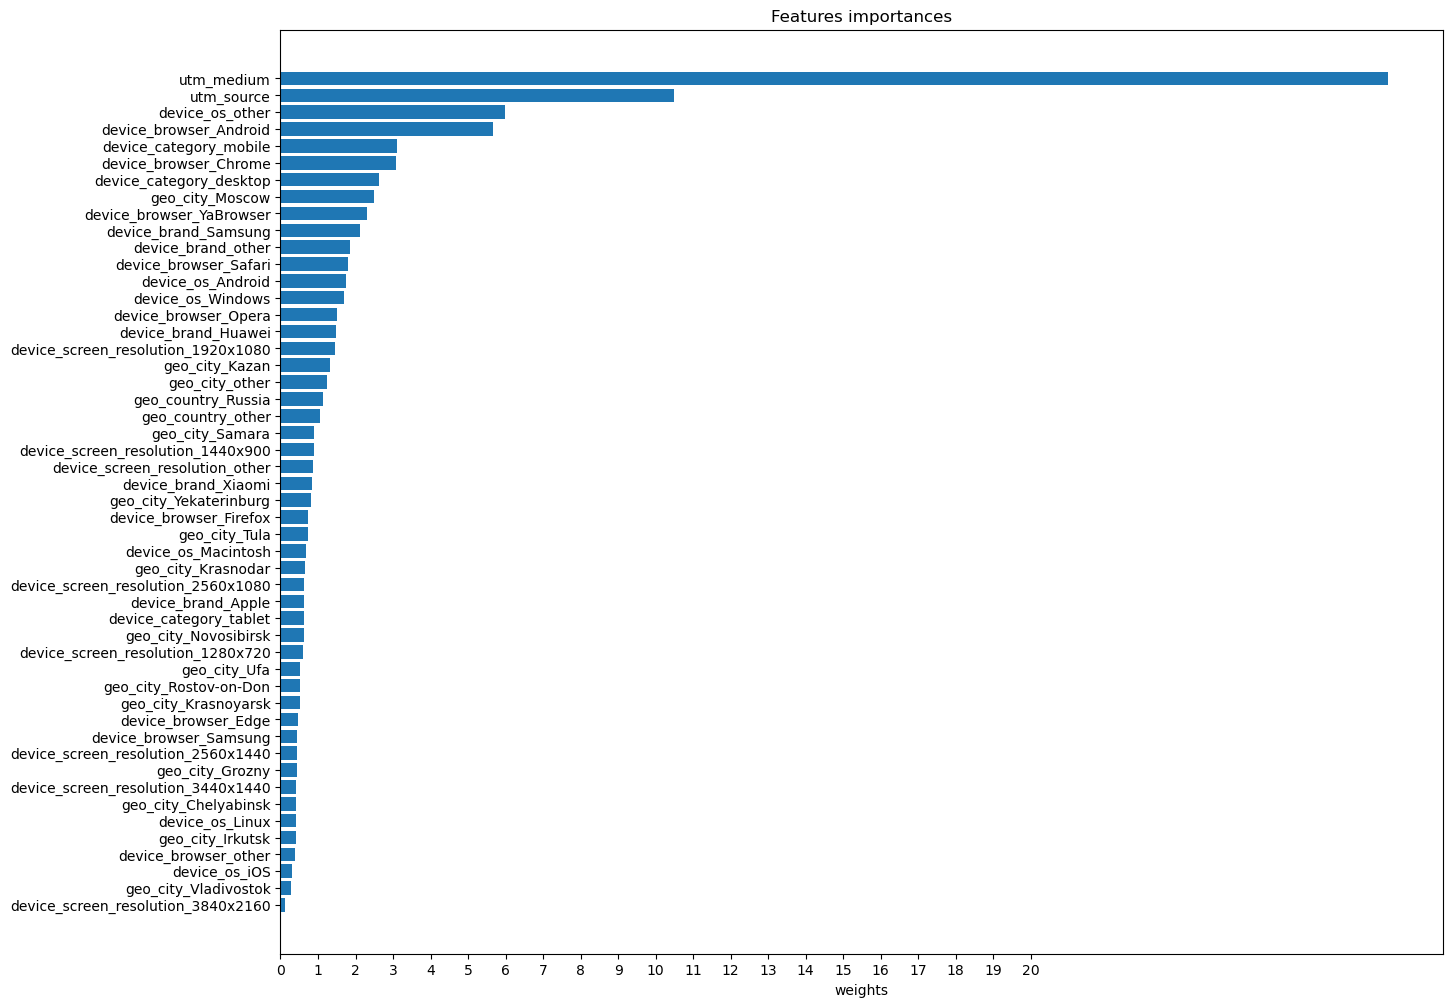

In [72]:
plt.figure(figsize=(15, 12))

plt.barh(imp_dict_sorted.keys(), imp_dict_sorted.values())
plt.xticks(np.arange(0, 21))
plt.xlabel('weights')
plt.title('Features importances')
plt.show()

# Model selection

In [73]:
X_train = df_train.drop(['target', 'session_id', 'client_id'], axis=1)
y_train = df_train['target']


model_list = [
    CatBoostClassifier(verbose=0), 
    XGBClassifier(tree_method='hist'), 
    HistGradientBoostingClassifier()
]

for model in model_list:
    pipe = Pipeline(steps=[
        ('binary_classificator', binary_clf),
        ('classificator', category_clf),
        ('encoder', encoder),
        ('scaler', MinMaxScaler()),
        ('estimator', model)
    ]) 

    score = cross_val_score(pipe, X_train, y_train, cv=4, scoring='roc_auc', n_jobs=-1, verbose=False)

    print(score)
    print(f'{model.__class__.__name__} - std_score: {score.std()}, mean_score: {score.mean()}')

[0.64662803 0.66600057 0.65456662 0.65472278]
CatBoostClassifier - std_score: 0.0069001348817672595, mean_score: 0.6554794983018563
[0.64809336 0.66545322 0.65569581 0.65435947]
XGBClassifier - std_score: 0.0062173650119840065, mean_score: 0.6559004665992462
[0.65041463 0.66850077 0.66005231 0.65742319]
HistGradientBoostingClassifier - std_score: 0.006471644160118755, mean_score: 0.6590977253884693


# Optuna

In [82]:
pipe = Pipeline(steps=[
        ('binary_classificator', binary_clf),
        ('classificator', category_clf),
        ('encoder', encoder),
        ('scaler', scaler)
    ]) 


X_train = df_train.drop(['target', 'session_id', 'client_id'], axis=1)
y_train = df_train['target']

X_test = df_test.drop(['target', 'session_id', 'client_id'], axis=1)
y_test = df_test['target']


X_train = pipe.fit_transform(X_train)
X_test = pipe.transform(X_test)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [83]:
X_train.head(3)

,utm_source,utm_medium,device_category_desktop,device_category_mobile,device_category_tablet,device_brand_Apple,device_brand_Huawei,device_brand_Samsung,device_brand_Xiaomi,device_brand_other,...,geo_city_Krasnoyarsk,geo_city_Moscow,geo_city_Novosibirsk,geo_city_Rostov-on-Don,geo_city_Samara,geo_city_Tula,geo_city_Ufa,geo_city_Vladivostok,geo_city_Yekaterinburg,geo_city_other
57007,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1605,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7178,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [84]:
X_train.shape

(61438, 50)

In [85]:
X_test.head(3)

,utm_source,utm_medium,device_category_desktop,device_category_mobile,device_category_tablet,device_brand_Apple,device_brand_Huawei,device_brand_Samsung,device_brand_Xiaomi,device_brand_other,...,geo_city_Krasnoyarsk,geo_city_Moscow,geo_city_Novosibirsk,geo_city_Rostov-on-Don,geo_city_Samara,geo_city_Tula,geo_city_Ufa,geo_city_Vladivostok,geo_city_Yekaterinburg,geo_city_other
37912,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
237018,0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1269758,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### HistGradientBoostingClassifier

In [77]:
def objective_rf(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 1e-1, log=True),
        'max_iter': trial.suggest_int('max_iter', 10, 1000)
    }

    model = HistGradientBoostingClassifier(**params)

    score = cross_val_score(
        model, X_train, y_train, cv=4, 
        scoring='roc_auc', n_jobs=-1, verbose=False
    ).mean()
        
    return score

hgbr_study = optuna.create_study(direction='maximize')
hgbr_study.optimize(objective_rf, n_trials=30)

[I 2026-01-15 13:12:22,909] A new study created in memory with name: no-name-42d44d87-d653-400c-8720-1670f64a390d
[I 2026-01-15 13:12:25,378] Trial 0 finished with value: 0.6571549423307634 and parameters: {'max_depth': 16, 'learning_rate': 0.03473713899503145, 'max_iter': 29}. Best is trial 0 with value: 0.6571549423307634.
[I 2026-01-15 13:12:29,144] Trial 1 finished with value: 0.6594301706350434 and parameters: {'max_depth': 17, 'learning_rate': 0.03258092500996938, 'max_iter': 755}. Best is trial 1 with value: 0.6594301706350434.
[I 2026-01-15 13:12:31,567] Trial 2 finished with value: 0.6595626510602124 and parameters: {'max_depth': 9, 'learning_rate': 0.05399076459415111, 'max_iter': 814}. Best is trial 2 with value: 0.6595626510602124.
[I 2026-01-15 13:12:33,331] Trial 3 finished with value: 0.659742518857164 and parameters: {'max_depth': 20, 'learning_rate': 0.08404746250511728, 'max_iter': 90}. Best is trial 3 with value: 0.659742518857164.
[I 2026-01-15 13:12:47,121] Trial 4

In [86]:
print(hgbr_study.best_value)
print(hgbr_study.best_params)

0.659742518857164
{'max_depth': 20, 'learning_rate': 0.08404746250511728, 'max_iter': 90}


In [87]:
hgbr_best_params = hgbr_study.best_params
hgbr = HistGradientBoostingClassifier(**hgbr_best_params)

In [92]:
hgbr.fit(X_train, y_train)

pred = hgbr.predict(X_test)
pred_probs = hgbr.predict_proba(X_test)[:, 1]

print(f'roc_auc: {roc_auc_score(y_test, pred_probs)}\n')
print(f'confusion maxrix\n {confusion_matrix(y_test, pred)}\n')
print(f'classification_report\n {classification_report(y_test, pred)}')

roc_auc: 0.6586002629453719

confusion maxrix
 [[265233 117815]
 [  6150   7015]]

classification_report
               precision    recall  f1-score   support

           0       0.98      0.69      0.81    383048
           1       0.06      0.53      0.10     13165

    accuracy                           0.69    396213
   macro avg       0.52      0.61      0.46    396213
weighted avg       0.95      0.69      0.79    396213



### CatBoostClassifier

In [93]:
def objective_rf(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-2, 1e-1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 1000, 2500)
    }

    model = CatBoostClassifier(eval_metric='AUC', verbose=0, **params)
    
    score = cross_val_score(
        model, X_train, y_train, cv=4, 
        scoring='roc_auc', n_jobs=-1, verbose=False
    ).mean()
        
    return score

cat_study = optuna.create_study(direction='maximize')
cat_study.optimize(objective_rf, n_trials=15)

[I 2026-01-15 13:21:37,564] A new study created in memory with name: no-name-adf6fe63-64d8-4b8d-9805-d87652edd933
[I 2026-01-15 13:21:58,577] Trial 0 finished with value: 0.6522672979852153 and parameters: {'max_depth': 5, 'learning_rate': 0.09390219159520583, 'n_estimators': 2035}. Best is trial 0 with value: 0.6522672979852153.
[I 2026-01-15 13:22:09,044] Trial 1 finished with value: 0.6551849069164941 and parameters: {'max_depth': 5, 'learning_rate': 0.083662549626991, 'n_estimators': 1030}. Best is trial 1 with value: 0.6551849069164941.
[I 2026-01-15 13:22:37,334] Trial 2 finished with value: 0.6474272653183096 and parameters: {'max_depth': 8, 'learning_rate': 0.06692763947931094, 'n_estimators': 2139}. Best is trial 1 with value: 0.6551849069164941.
[I 2026-01-15 13:23:00,602] Trial 3 finished with value: 0.6542172018895298 and parameters: {'max_depth': 4, 'learning_rate': 0.08371717383708117, 'n_estimators': 2428}. Best is trial 1 with value: 0.6551849069164941.
[I 2026-01-15 13

In [94]:
print(cat_study.best_value)
print(cat_study.best_params)

0.6585532271969491
{'max_depth': 6, 'learning_rate': 0.010382221313419943, 'n_estimators': 2484}


In [95]:
cat_best_params = cat_study.best_params
cat = CatBoostClassifier(eval_metric='AUC', verbose=0, **cat_best_params)

In [96]:
cat.fit(X_train, y_train)

pred = cat.predict(X_test)
pred_probs = cat.predict_proba(X_test)[:, 1]

print(f'roc_auc: {roc_auc_score(y_test, pred_probs)}\n')
print(f'confusion maxrix\n {confusion_matrix(y_test, pred)}\n')
print(f'classification_report\n {classification_report(y_test, pred)}')

roc_auc: 0.6585617416946763

confusion maxrix
 [[243667 139381]
 [  5367   7798]]

classification_report
               precision    recall  f1-score   support

           0       0.98      0.64      0.77    383048
           1       0.05      0.59      0.10     13165

    accuracy                           0.63    396213
   macro avg       0.52      0.61      0.43    396213
weighted avg       0.95      0.63      0.75    396213

